# Filamentation SiO2 — 1030 nm, 4 µJ

| | |
|---|---|
| sonde | 515 nm |
| énergie | 4 µJ incidents (frame expérimentale du 20260804) |
| profil 1/e² | sx/sy = 11.5 / 11.0 µm → rayon équivalent 11.25 µm |
| waist | z = 0 |
| boîte | 0 → 350 µm |
| tracés | r = (−70, 70) µm, z = (0, 350) µm, OPL (nm) et transmittance |

Exécuter les cellules dans l'ordre.


## Installation des dépendances

À exécuter en premier. Le post-traitement ne demande que numpy / scipy / matplotlib ; `cupy` n'est nécessaire que pour lancer un nouveau calcul sur GPU.


In [1]:
# [deps-install-cell]
# ============================================================================
#  Installation des dependances
# ============================================================================
# A executer une fois, en premier. Si cupy est installe par cette cellule,
# REDEMARRER LE NOYAU avant de continuer.
#
# Deux niveaux :
#   - CPU  : numpy / scipy / matplotlib (+ pillow). Suffisent pour tout
#            le POST-TRAITEMENT, c'est-a-dire relire un result.npz deja calcule
#            et regenerer les figures.
#   - GPU  : cupy. Necessaire uniquement pour LANCER un calcul
#            (filament_sim.run()), qui est un solveur CUDA.
import importlib
import importlib.util
import re
import shutil
import subprocess
import sys

REQUIRED = ["numpy", "scipy", "matplotlib", "pillow","tqdm"]
_IMPORT_NAME = {"pillow": "PIL", "ipywidgets": "ipywidgets"}


def _pip(*args):
    print("  pip install", *args)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])


print("Dependances CPU :")
for pkg in REQUIRED:
    mod = _IMPORT_NAME.get(pkg, pkg)
    if importlib.util.find_spec(mod) is None:
        _pip(pkg)
    else:
        print(f"  {pkg:12s} deja present")

print("\nDependance GPU (cupy) :")
if importlib.util.find_spec("cupy") is not None:
    import cupy
    print(f"  cupy {cupy.__version__} deja present")
    try:
        print(f"  GPU visible : {cupy.cuda.runtime.getDeviceCount()} device(s)")
    except Exception as exc:
        print(f"  /!\\ cupy importe mais aucun GPU utilisable ({type(exc).__name__})")
else:
    # La roue cupy depend de la version de CUDA du pilote : il n'existe pas de
    # paquet "cupy" generique qui marche partout, d'ou la detection.
    cuda_major = None
    if shutil.which("nvidia-smi"):
        try:
            out = subprocess.check_output(["nvidia-smi"], text=True)
            m = re.search(r"CUDA Version:\s*(\d+)\.", out)
            cuda_major = int(m.group(1)) if m else None
        except Exception:
            pass
    if cuda_major is None:
        print("  aucun GPU NVIDIA detecte -> cupy N'EST PAS installe.")
        print("  Le post-traitement fonctionne quand meme sur un result.npz")
        print("  deja calcule ; seul filament_sim.run() a besoin du GPU.")
    else:
        _pip(f"cupy-cuda{12 if cuda_major >= 12 else 11}x")
        print("  cupy installe -> REDEMARRER LE NOYAU avant de continuer.")

print("\nVersions :")
for _m in ("numpy", "scipy", "matplotlib"):
    try:
        print(f"  {_m:12s} {importlib.import_module(_m).__version__}")
    except ImportError:
        print(f"  {_m:12s} ABSENT")


Dependances CPU :
  numpy        deja present
  pip install scipy
  pip install matplotlib
  pillow       deja present
  pip install tqdm

Dependance GPU (cupy) :
  pip install cupy-cuda12x
  cupy installe -> REDEMARRER LE NOYAU avant de continuer.

Versions :
  numpy        2.1.2
  scipy        1.18.0
  matplotlib   3.11.1


## 0. Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c as c_SI, epsilon_0, m_e, elementary_charge as q_e

# --- localisation des modules du depot ------------------------------------
# Ce notebook a besoin de l'arborescence "deliverable (3)/{sim,web,notebooks}",
# pas seulement du fichier .ipynb. On cherche sim/ depuis le repertoire courant
# puis en remontant, ce qui marche que le noyau soit lance depuis notebooks/,
# depuis la racine du depot, ou ailleurs.
SIM_DIR = None   # <- mettre ici le chemin de sim/ si la recherche echoue


def _resolve_pkg_dirs(explicit=None):
    roots = []
    if explicit:
        p = Path(explicit).expanduser().resolve()
        roots.append(p.parent if p.name == "sim" else p)
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        roots += [base, base / "deliverable (3)",
                  base / ".github" / "deliverable (3)"]
    for root in roots:
        if (root / "sim" / "filament_sim.py").is_file():
            return {n: root / n for n in ("sim", "web") if (root / n).is_dir()}
    return {}


_dirs = _resolve_pkg_dirs(SIM_DIR)
if not _dirs:
    raise ModuleNotFoundError(
        "dossier sim/ introuvable."
        "\n  repertoire courant : " + str(Path.cwd()) +
        "\n  Ce notebook a besoin de l'arborescence complete du depot, pas"
        "\n  seulement du .ipynb. Recupere le dossier 'deliverable (3)' entier"
        "\n  (sim/, web/, notebooks/) et lance le noyau depuis"
        "\n  'deliverable (3)/notebooks/', ou renseigne SIM_DIR ci-dessus.")
for _n, _d in _dirs.items():
    sys.path.insert(0, str(_d))
print("modules du depot :", _dirs["sim"])

from filament_sim import run, FIELD_TOGGLES, n_sellmeier
import figures_filament as ff
import figures_report as fr

OUT_ROOT = Path("runs_z0")
FIG_DIR = OUT_ROOT / "figures"
REP_DIR = OUT_ROOT / "figures_rapport"
OUT_ROOT.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
REP_DIR.mkdir(exist_ok=True)
print("toggles :", FIELD_TOGGLES)

modules du depot : /workspace/1630/sim
toggles : ['enable_kerr_instantaneous', 'enable_kerr_raman', 'enable_self_steepening', 'enable_photoionization_loss', 'enable_plasma_defocusing', 'enable_plasma_absorption']


## 1. Paramètres

In [3]:
# ---------------- laser ----------------
WAVELENGTH_M = 1030e-9
SX_UM        = 11.5
SY_UM        = 11.0
W0_M         = np.sqrt(SX_UM * SY_UM) * 1e-6
DELTA_T_S    = 263e-15

FRESNEL_T           = 1.0 - ((1.45 - 1.0) / (1.45 + 1.0))**2
ENERGY_INCIDENT_UJ  = 4.0
ENERGY_SWEEP_INC_UJ = [4.0]

# ---------------- materiau ----------------
N2          = 2.74e-20
UI_EV       = 9.0
MEFF_REL    = 0.64   # masse reduite du taux de Keldysh
MEFF_DRUDE_REL = 1.0 # masse effective du terme de Drude (sigma, avalanche)
TAU_C_S     = 1.7e-15
TAU_R_S     = 330e-15
TAU_STE_S   = 1e-12
RHO_MAX_CM3 = 2.1e22
US_EV       = 6.0
E_TR_EV     = 4.2
F_R         = 0.18
TAU_D_S     = 32e-15
TAU_S_S     = 12e-15

# ---------------- sonde ----------------
LAMBDA_PROBE_M = 515e-9

# ---------------- boite ----------------
BEGIN_M = 0.0
END_M   = 350e-6

# ---------------- grille ----------------
# rho_t_stride fixe la RESOLUTION EN DELAI du cube (z, r, t), donc le pas de
# balayage temporel qui a encore un sens : l'interpolation est au plus proche
# voisin, en dessous du pas du cube la courbe devient un escalier. Le balayage
# fin de la manip est a 33 fs, donc il faut dt_cube nettement plus petit.
# rho_t_stride=8 donne 8.7 fs, avec de la marge. Le cube double de taille par
# rapport a 16 ; passer rho_r_stride a 4 le ramenerait a l'identique si la
# place manque.
FAST = dict(Nz=9000,  Nt=2048, Nr=1024, R_factor=8.0,
            save_stride=20, rho_t_stride=8, rho_r_stride=2)
PROD = dict(Nz=18000, Nt=4096, Nr=2048, R_factor=8.0,
            save_stride=40, rho_t_stride=8, rho_r_stride=4)
GRID = FAST

# ---------------- trace ----------------
Z_LIM_EXP = (0.0, 350.0)
R_LIM_EXP = (-70.0, 70.0)
X_HALF_UM = 75.0
DELAYS_FS = [-500, 0, 250, 500, 1000, 1500, 1901, 2000]  # 1901 fs = la frame experimentale

print("parametres definis")

parametres definis


## 2. Grandeurs dérivées

In [4]:
ENERGY_IN_GLASS_UJ = ENERGY_INCIDENT_UJ * FRESNEL_T
ENERGY_SWEEP_UJ    = [E * FRESNEL_T for E in ENERGY_SWEEP_INC_UJ]

n0 = n_sellmeier(WAVELENGTH_M)
k0 = 2.0 * np.pi * n0 / WAVELENGTH_M
zR = k0 * W0_M**2 / 2.0

tp   = DELTA_T_S / np.sqrt(2.0 * np.log(2.0))
tmax = 5.0 * tp
dt   = 2.0 * tmax / GRID["Nt"]
dz   = (END_M - BEGIN_M) / GRID["Nz"]
R_MAX = GRID["R_factor"] * W0_M
dr   = R_MAX / (GRID["Nr"] - 1)

n_saves = GRID["Nz"] // GRID["save_stride"] + 1
Nt_sub  = (GRID["Nt"] - 1) // GRID["rho_t_stride"] + 1
Nr_sub  = (GRID["Nr"] - 2) // GRID["rho_r_stride"] + 1

NC_PROBE = epsilon_0 * m_e * (2.0*np.pi*c_SI/LAMBDA_PROBE_M)**2 / q_e**2 * 1e-6

PROBE_KW = dict(lambda_probe_m=LAMBDA_PROBE_M, E_tr_eV=E_TR_EV, n2=N2,
                tau_c_s=TAU_C_S, tau_r_s=TAU_R_S, tau_ste_s=TAU_STE_S)

print(f"w0        = {W0_M*1e6:.2f} um       z_R = {zR*1e6:.0f} um")
print(f"sonde     = {LAMBDA_PROBE_M*1e9:.0f} nm     n_c = {NC_PROBE:.3e} cm-3")
print(f"energie   = {ENERGY_INCIDENT_UJ} uJ incidents -> {ENERGY_IN_GLASS_UJ:.3f} uJ dans le verre")
print(f"balayage  = {ENERGY_SWEEP_INC_UJ} uJ incidents")
print(f"z : Nz={GRID['Nz']}  dz={dz*1e9:.1f} nm  |  {n_saves} plans, dz_save={dz*GRID['save_stride']*1e6:.2f} um")
print(f"r : R_max={R_MAX*1e6:.0f} um  dr={dr*1e9:.0f} nm  ({W0_M/dr:.0f} pts dans w0)")
print(f"t : Nt={GRID['Nt']}  dt={dt*1e15:.2f} fs  f_Nyq/f0={1.0/(2*dt)/(c_SI/WAVELENGTH_M):.2f}")
print(f"cube (z,r,t) : {3*n_saves*Nr_sub*Nt_sub*4/1e6:.0f} Mo")
DT_CUBE_FS = 2.0 * tmax * 1e15 / (Nt_sub - 1)
print(f"delai     : dt_cube={DT_CUBE_FS:.1f} fs "
      f"({'OK pour un balayage a 33 fs' if DT_CUBE_FS < 33 else 'TROP GROSSIER pour 33 fs'})")

w0        = 11.25 um       z_R = 559 um
sonde     = 515 nm     n_c = 4.203e+21 cm-3
energie   = 4.0 uJ incidents -> 3.865 uJ dans le verre
balayage  = [4.0] uJ incidents
z : Nz=9000  dz=38.9 nm  |  451 plans, dz_save=0.78 um
r : R_max=90 um  dr=88 nm  (128 pts dans w0)
t : Nt=2048  dt=1.09 fs  f_Nyq/f0=1.58
cube (z,r,t) : 709 Mo
delai     : dt_cube=8.8 fs (OK pour un balayage a 33 fs)


## 3. Contrôles avant lancement

In [5]:
P_cr = ff.critical_power(N2, WAVELENGTH_M, n0)
print(f"P_cr = {P_cr*1e-6:.2f} MW\n")

for E_inc, E_gl in zip(ENERGY_SWEEP_INC_UJ, ENERGY_SWEEP_UJ):
    P_in = E_gl * 1e-6 / (tp * np.sqrt(np.pi / 2.0))
    ratio, L_DF, L_c, _ = ff.marburger_collapse(P_in, P_cr, W0_M, WAVELENGTH_M, n0)
    print(f"--- {E_inc:g} uJ incidents ({E_gl:.2f} uJ verre) ---")
    ff.check_entrance_intensity(E_gl, W0_M, DELTA_T_S, BEGIN_M, WAVELENGTH_M, n0)
    print(f"  P/P_cr = {ratio:.1f}   L_c = {L_c*1e6:.0f} um\n")

P_cr = 4.01 MW

--- 4 uJ incidents (3.87 uJ verre) ---
  P_crete   = 13.8 MW
  I au waist= 6.95e+12 W/cm2   (0.1 x I_clamp)
  w(entree) = 11.2 um  ->  I(entree) = 6.95e+12 W/cm2
  OK : 7.2 x sous le clampage a l'entree.
  P/P_cr = 3.4   L_c = 207 um



## 4. Les trois runs

In [6]:
sweep = {}

for E_inc, E_gl in zip(ENERGY_SWEEP_INC_UJ, ENERGY_SWEEP_UJ):
    tag = f"{E_inc:g}uJ"
    out_dir = str(OUT_ROOT / f"z0_350um_{tag}")
    result = ff.load_scenario_npz(out_dir)
    if result is None:
        print(f"\n=== lancement {tag} ===")
        result = run(
            Nz=GRID["Nz"], Nt=GRID["Nt"], Nr=GRID["Nr"], R_factor=GRID["R_factor"],
            begin=BEGIN_M, end=END_M,
            save_stride=GRID["save_stride"], ckpt_every=200, verbose=True,
            wavelength=WAVELENGTH_M, energy_uJ=E_gl,
            w0=W0_M, delta_t=DELTA_T_S,
            n2=N2, Ui_eV=UI_EV, meff_rel=MEFF_REL,
            tau_c=TAU_C_S, tau_r=TAU_R_S, rho_max=RHO_MAX_CM3,
            Us_eV=US_EV, tau_ste=TAU_STE_S,
            f_R=F_R, tau_d=TAU_D_S, tau_s=TAU_S_S,
            enable_ste=True, lambda_probe=LAMBDA_PROBE_M,
            rho_t_stride=GRID["rho_t_stride"], rho_r_stride=GRID["rho_r_stride"],
            out_dir=out_dir, envelope="gaussian_focused",
        )
    sweep[tag] = result
    ff.run_health_check(result, out_dir=out_dir, label=tag, rho_max=RHO_MAX_CM3)
    print()

res = sweep[f"{ENERGY_INCIDENT_UJ:g}uJ"]
print("runs disponibles :", list(sweep))


=== lancement 4uJ ===
[init] U_beam(0) = 3.865 uJ 
[init] result.npz ~ 0.71 GB non compresse (94 % = cube (z,r,t))


Filamentation:   0%|          | 0/9001 [00:00<?, ?step/s]

=== 4uJ ===
  I_max            = 4.130e+13 W/cm2 @ z_sim=+350 um   [attendu 4.5e+13-5.5e+13 -> HORS BANDE]
  rho_e max        = 1.013e+20 cm-3   [ref 2e+20-4e+20 (Couairon 2005 @800nm, 1.1uJ, w0=1um) -> HORS BANDE]
  rho_s max (STE)  = 7.555e+19 cm-3
  pertes totales   = 14.0 %  ->  transmission 86.0 %
  enable_spectral_filter           = True
  enable_space_time_focusing       = True
  enable_ste                       = True

runs disponibles : ['4uJ']


## 5. Diagnostics

4uJ
0 maximum(aux) local(aux) au-dessus de I_clamp=5e+13 et de proeminence > 30% :


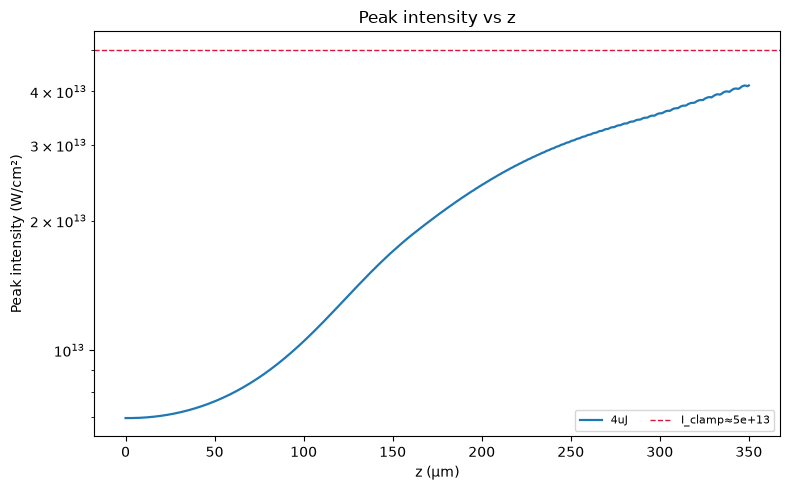

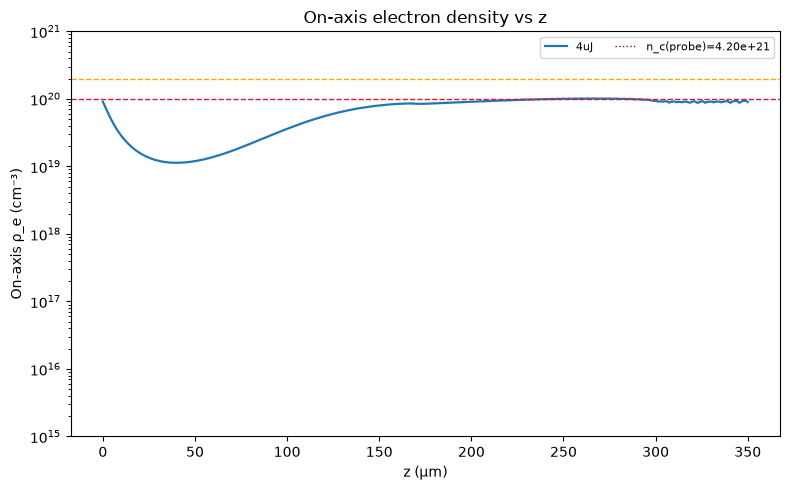

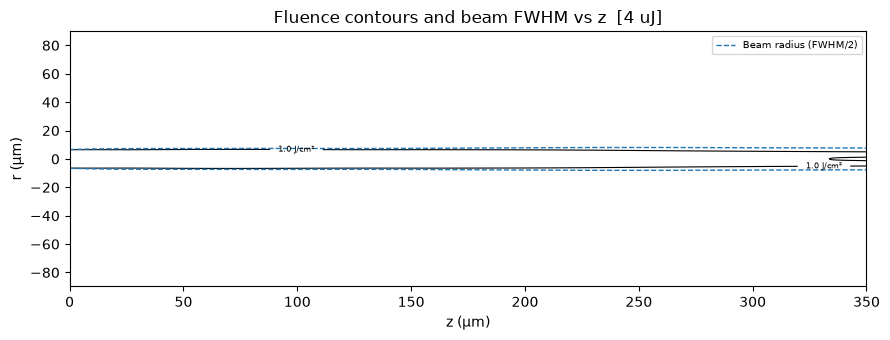

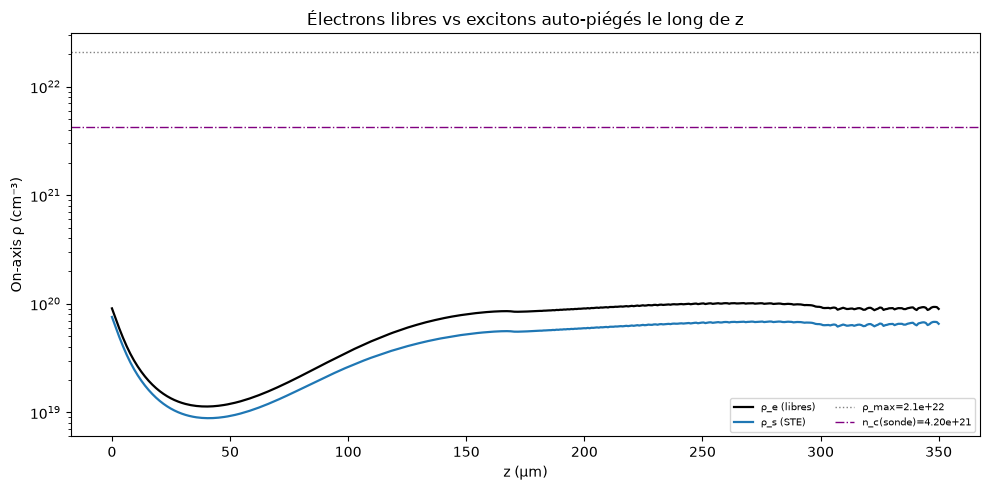

In [7]:
ff.plot_fig8_peak_intensity(sweep, save=str(FIG_DIR / "peak_intensity.png"))
ff.plot_fig9_electron_density(sweep, nc_probe_cm3=NC_PROBE,
                              save=str(FIG_DIR / "rho_e.png"))
ff.plot_fig7_fluence_contours(res, levels=(1.0, 5.0, 20.0, 50.0),
                              label=f"{ENERGY_INCIDENT_UJ:g} uJ",
                              save=str(FIG_DIR / "fluence.png"))
ff.plot_free_vs_trapped_vs_z(res, rho_max_cm3=RHO_MAX_CM3, nc_probe_cm3=NC_PROBE,
                             save=str(FIG_DIR / "rho_e_rho_s.png"))

for tag in sweep:
    print(tag)
    ff.count_refocusing_cycles(sweep[tag])

## 6. Planches OPL + transmittance

Format expérimental exact : `r = (−70, 70) µm`, `z = (0, 350) µm`.

4uJ        +0 fs :  OPL max =    26.80 nm   T min = 1.000
4uJ      +500 fs :  OPL max =    31.11 nm   T min = 0.945
4uJ     +1000 fs :  OPL max =    36.33 nm   T min = 0.917



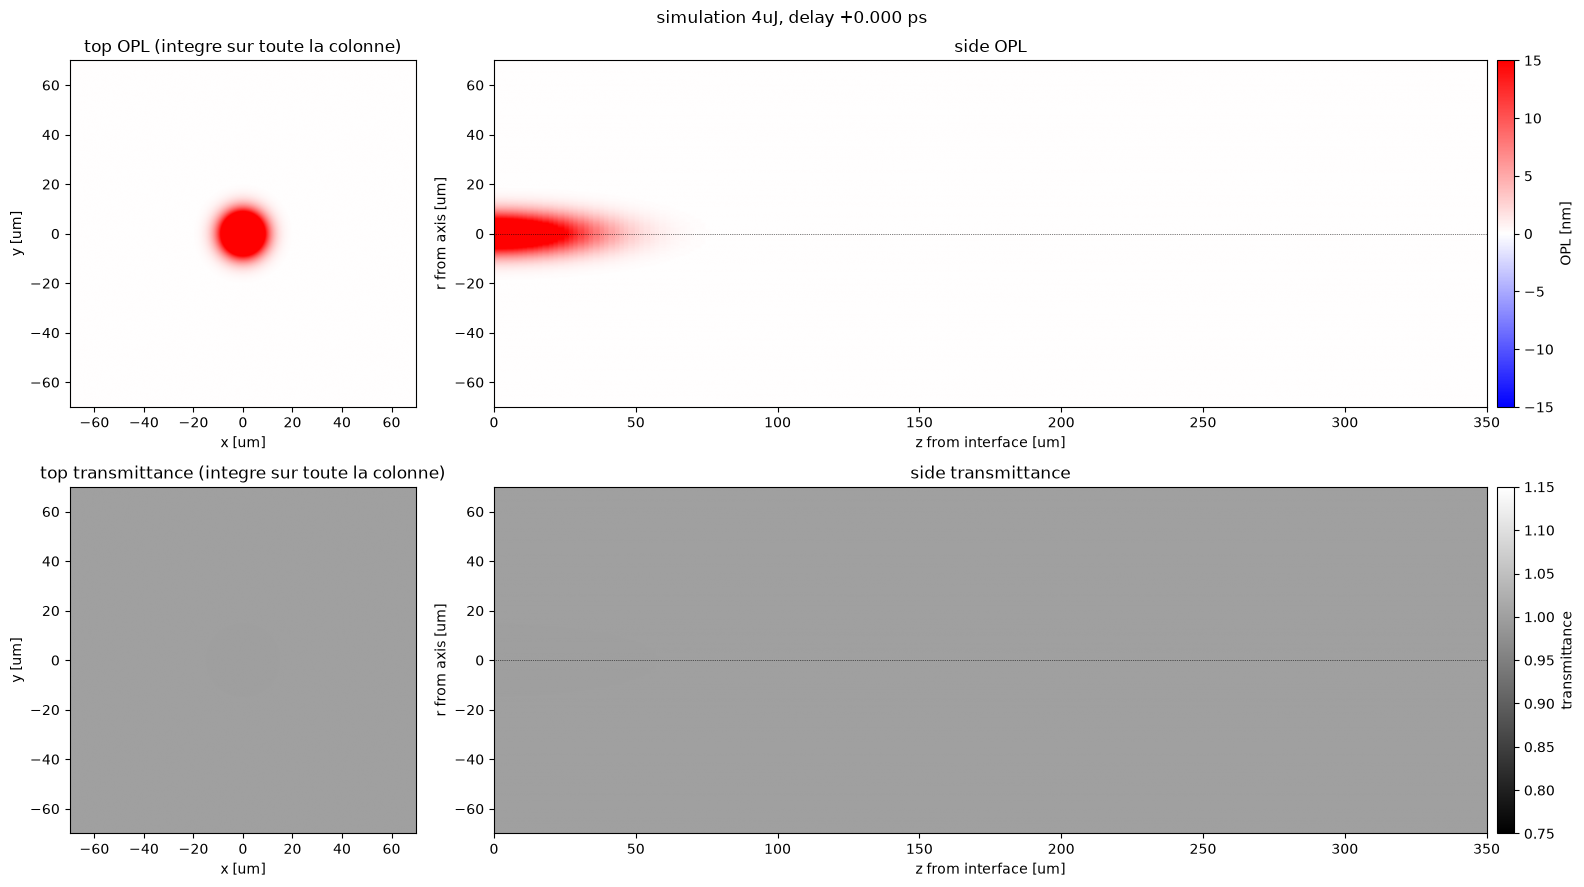

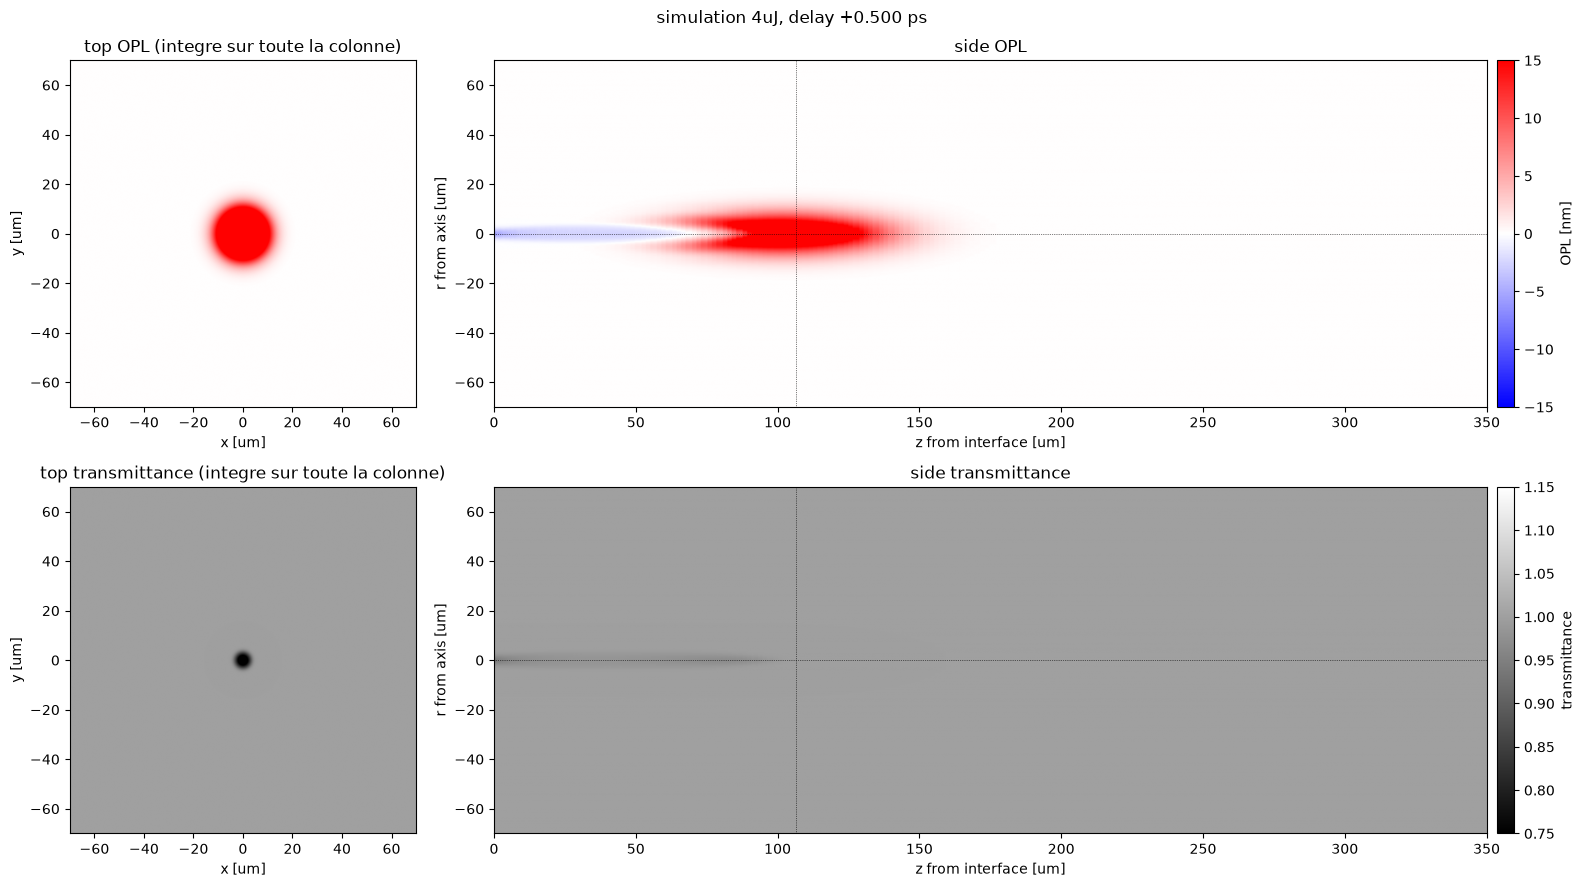

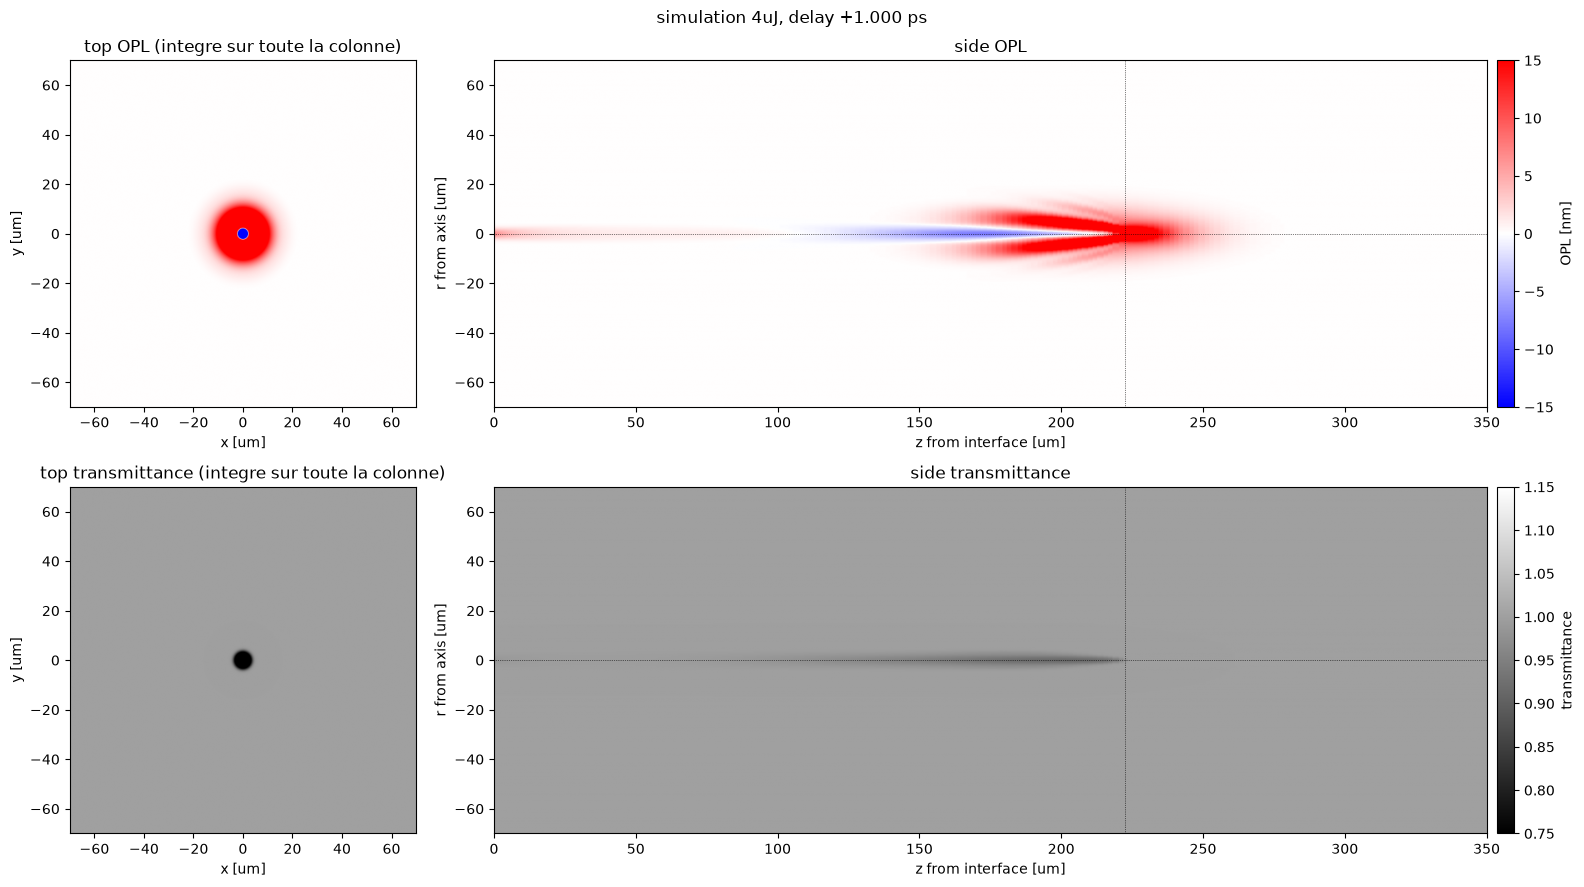

In [8]:
for tag in sweep:
    for delay in (0.0, 500.0, 1000.0):
        fig, diag = ff.plot_opl_panel(
            sweep[tag], delay_fs=delay,
            z_lim=Z_LIM_EXP, r_lim=R_LIM_EXP, x_half_um=X_HALF_UM,
            opl_clip_nm=15.0, t_lim=(0.75, 1.15),
            rho_max_cm3=RHO_MAX_CM3, validity_frac=0.1,
            title=f"simulation {tag}, delay {delay/1000:+.3f} ps",
            save=str(FIG_DIR / f"opl_{tag}_{delay:+05.0f}fs.png"),
            **PROBE_KW)
        print(f"{tag:6s} {delay:+6.0f} fs :"
              f"  OPL max = {np.abs(diag['opl_nm']).max():8.2f} nm"
              f"   T min = {diag['transmittance'].min():.3f}")
    print()

## 6b. Contrôles d'intégration

Les planches reposent sur deux intégrales numériques sans vérité de référence :
la transformée d'Abel le long de la corde (vue de côté) et l'intégrale sur `z`
(vue de dessus). On les contrôle par des invariants.

Le plus fort est le n° 5 : les deux vues intègrent le même `Δn` sur le même
volume, donc

$$\iint \mathrm{OPL}_{\text{côté}}\,\mathrm{d}x\,\mathrm{d}z \;=\; \iint \mathrm{OPL}_{\text{dessus}}\,\mathrm{d}x\,\mathrm{d}y$$

quelle que soit la physique. Un écart signale une erreur d'intégration, pas de modèle.


In [9]:
for delay in (0.0, 500.0, 1901.0):
    ff.check_integration(res, delay_fs=delay, x_half_um=X_HALF_UM, **PROBE_KW)
    print()


Controles d'integration, delai +0 fs
  OK  1. matrice d'Abel vs gaussienne analytique : erreur relative max 0.01%
  OK  2. invariant int F dx = 2pi int f r dr : ecart max 0.02% (a z = 0 um)
  OK  3. troncature radiale : |dn| au bord r = 90 um vaut 0.00% du max
  /!\ 4a. bord z = 0 um : 100.0% du max -> la colonne ENTRE deja excitee
  OK  4b. bord z = 350 um : 0.0% du max -> la colonne est refermee
  OK  5. invariant inter-panneau cote/dessus : ecart 0.020% (1.086e+04 vs 1.086e+04 nm.um2)
  OK  6. trapeze vs Simpson sur l'integrale en z : 0.001%

Controles d'integration, delai +500 fs
  OK  1. matrice d'Abel vs gaussienne analytique : erreur relative max 0.01%
  OK  2. invariant int F dx = 2pi int f r dr : ecart max 0.03% (a z = 110 um)
  OK  3. troncature radiale : |dn| au bord r = 90 um vaut 0.00% du max
  /!\ 4a. bord z = 0 um : 50.5% du max -> la colonne ENTRE deja excitee
  OK  4b. bord z = 350 um : 0.0% du max -> la colonne est refermee
  OK  5. invariant inter-panneau cote/dessus

### Bilan d'absorption

L'expérience donne **deux** transmittances pour le même plasma, avec des
longueurs de trajet très différentes : la vue de côté traverse une corde de
quelques µm, la vue de dessus toute la colonne. Le rapport des profondeurs
optiques est fixé par la géométrie et **ne dépend pas de σ** — c'est un test du
traitement, indépendant de tout modèle. Les valeurs absolues testent ensuite σ
et ρ_e.

Renseigner `T_MEASURED`, `CHORD_UM` et `COLUMN_UM` d'après la planche mesurée.


In [10]:
T_MEASURED = 0.90     # T minimale lue sur la vue de COTE
CHORD_UM   = 5.0      # epaisseur du canal traverse par la sonde, vue de cote
COLUMN_UM  = 330.0    # longueur de la colonne, vue de dessus

print("=== modele historique ===")
ff.absorption_budget(res, 1901.0, x_half_um=X_HALF_UM, T_measured=T_MEASURED,
                     chord_um=CHORD_UM, column_um=COLUMN_UM, **PROBE_KW)

print("\n=== modele de permittivite (Martin et al. 1997) ===")
from permittivity import SIO2_MARTIN1997
ff.absorption_budget(res, 1901.0, x_half_um=X_HALF_UM, T_measured=T_MEASURED,
                     chord_um=CHORD_UM, column_um=COLUMN_UM,
                     material=SIO2_MARTIN1997, **PROBE_KW)

print()
ff.compare_probe_models(res, 1901.0, x_half_um=X_HALF_UM, **PROBE_KW)


=== modele historique ===
Bilan d'absorption, delai +1901 fs
  sigma sonde      = 3.113e-18 cm2
  rho_e max        = 4.648e+19 cm-3
  simule, de cote  : T min = 0.9607  (tau = 0.0401)
  simule, de dessus: T min = 0.3806  (tau = 0.9661)
  mesure           : T = 0.900  (tau = 0.1054)
  rapport tau simule/mesure, de cote : 0.38
  rho_e qu'il faudrait sur une corde de 5 um : 6.768e+19 cm-3
  identite geometrique attendue sur les DONNEES : tau_dessus/tau_cote = 66.0

=== modele de permittivite (Martin et al. 1997) ===
Bilan d'absorption, delai +1901 fs
  sigma sonde      = 1.394e-17 cm2
  rho_e max        = 4.648e+19 cm-3
  simule, de cote  : T min = 0.8274  (tau = 0.1895)
  simule, de dessus: T min = 0.0054  (tau = 5.2125)
  mesure           : T = 0.900  (tau = 0.1054)
  rapport tau simule/mesure, de cote : 1.80
  rho_e qu'il faudrait sur une corde de 5 um : 1.511e+19 cm-3
  identite geometrique attendue sur les DONNEES : tau_dessus/tau_cote = 66.0

Sonde 515 nm, delai +1901 fs
  historiqu

{'legacy': {'x_um': array([-75.  , -74.75, -74.5 , -74.25, -74.  , -73.75, -73.5 , -73.25,
         -73.  , -72.75, -72.5 , -72.25, -72.  , -71.75, -71.5 , -71.25,
         -71.  , -70.75, -70.5 , -70.25, -70.  , -69.75, -69.5 , -69.25,
         -69.  , -68.75, -68.5 , -68.25, -68.  , -67.75, -67.5 , -67.25,
         -67.  , -66.75, -66.5 , -66.25, -66.  , -65.75, -65.5 , -65.25,
         -65.  , -64.75, -64.5 , -64.25, -64.  , -63.75, -63.5 , -63.25,
         -63.  , -62.75, -62.5 , -62.25, -62.  , -61.75, -61.5 , -61.25,
         -61.  , -60.75, -60.5 , -60.25, -60.  , -59.75, -59.5 , -59.25,
         -59.  , -58.75, -58.5 , -58.25, -58.  , -57.75, -57.5 , -57.25,
         -57.  , -56.75, -56.5 , -56.25, -56.  , -55.75, -55.5 , -55.25,
         -55.  , -54.75, -54.5 , -54.25, -54.  , -53.75, -53.5 , -53.25,
         -53.  , -52.75, -52.5 , -52.25, -52.  , -51.75, -51.5 , -51.25,
         -51.  , -50.75, -50.5 , -50.25, -50.  , -49.75, -49.5 , -49.25,
         -49.  , -48.75, -48.5 , 

## 7. Série de délais (run de référence)

  -500 fs :  OPL max =     0.00 nm   T min = 1.000
    +0 fs :  OPL max =    26.80 nm   T min = 1.000
  +250 fs :  OPL max =    27.73 nm   T min = 0.905
  +500 fs :  OPL max =    31.11 nm   T min = 0.945
 +1000 fs :  OPL max =    36.33 nm   T min = 0.917
 +1500 fs :  OPL max =    37.35 nm   T min = 0.935
 +1901 fs :  OPL max =     5.87 nm   T min = 0.961
 +2000 fs :  OPL max =     5.76 nm   T min = 0.971


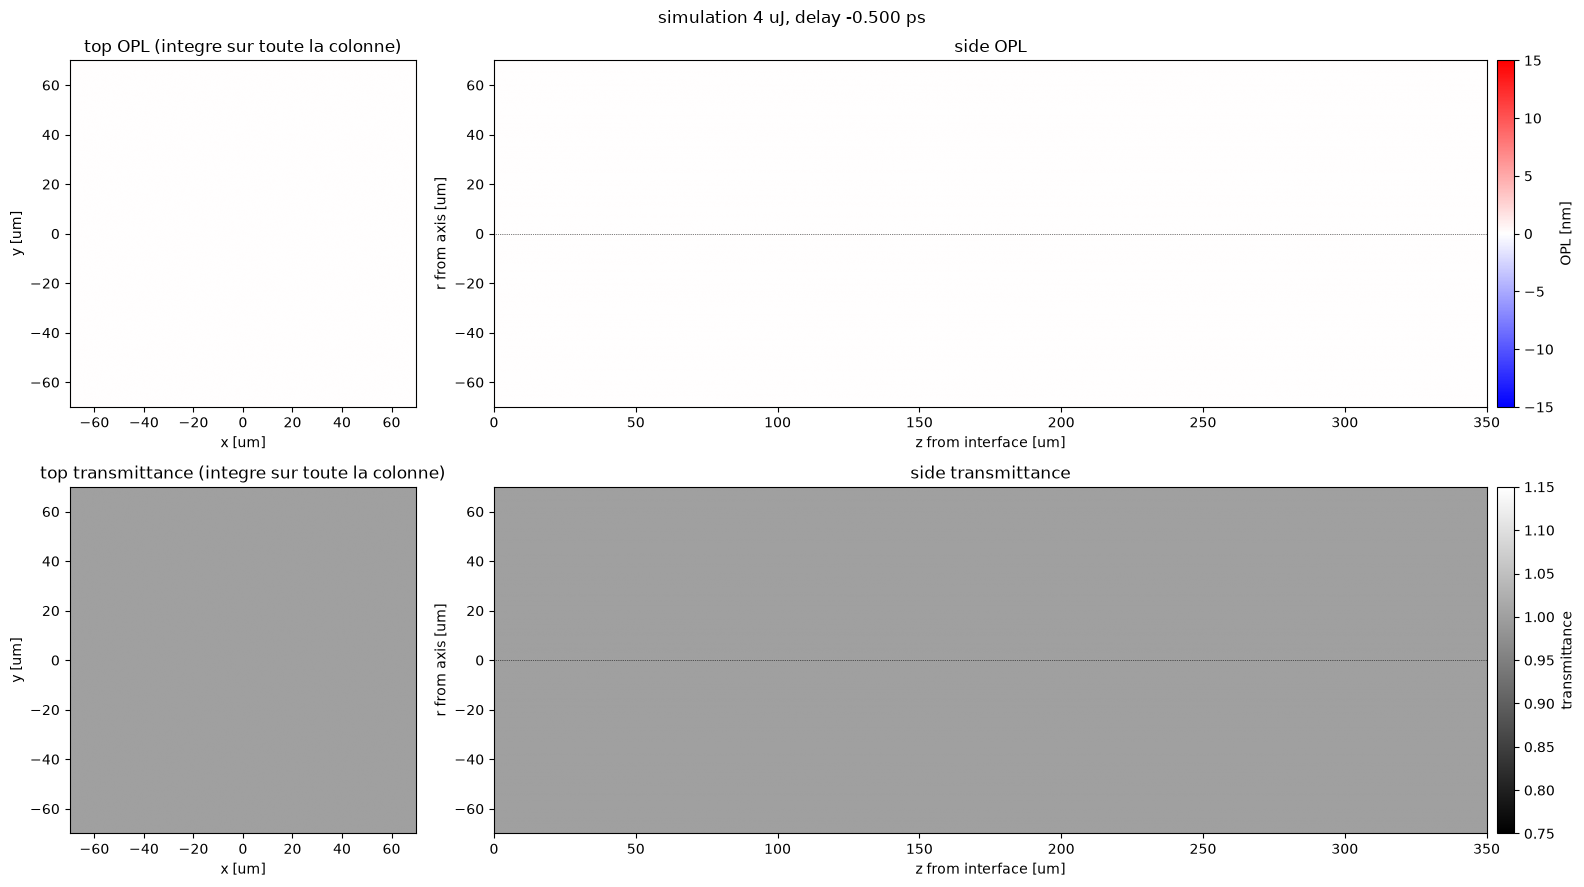

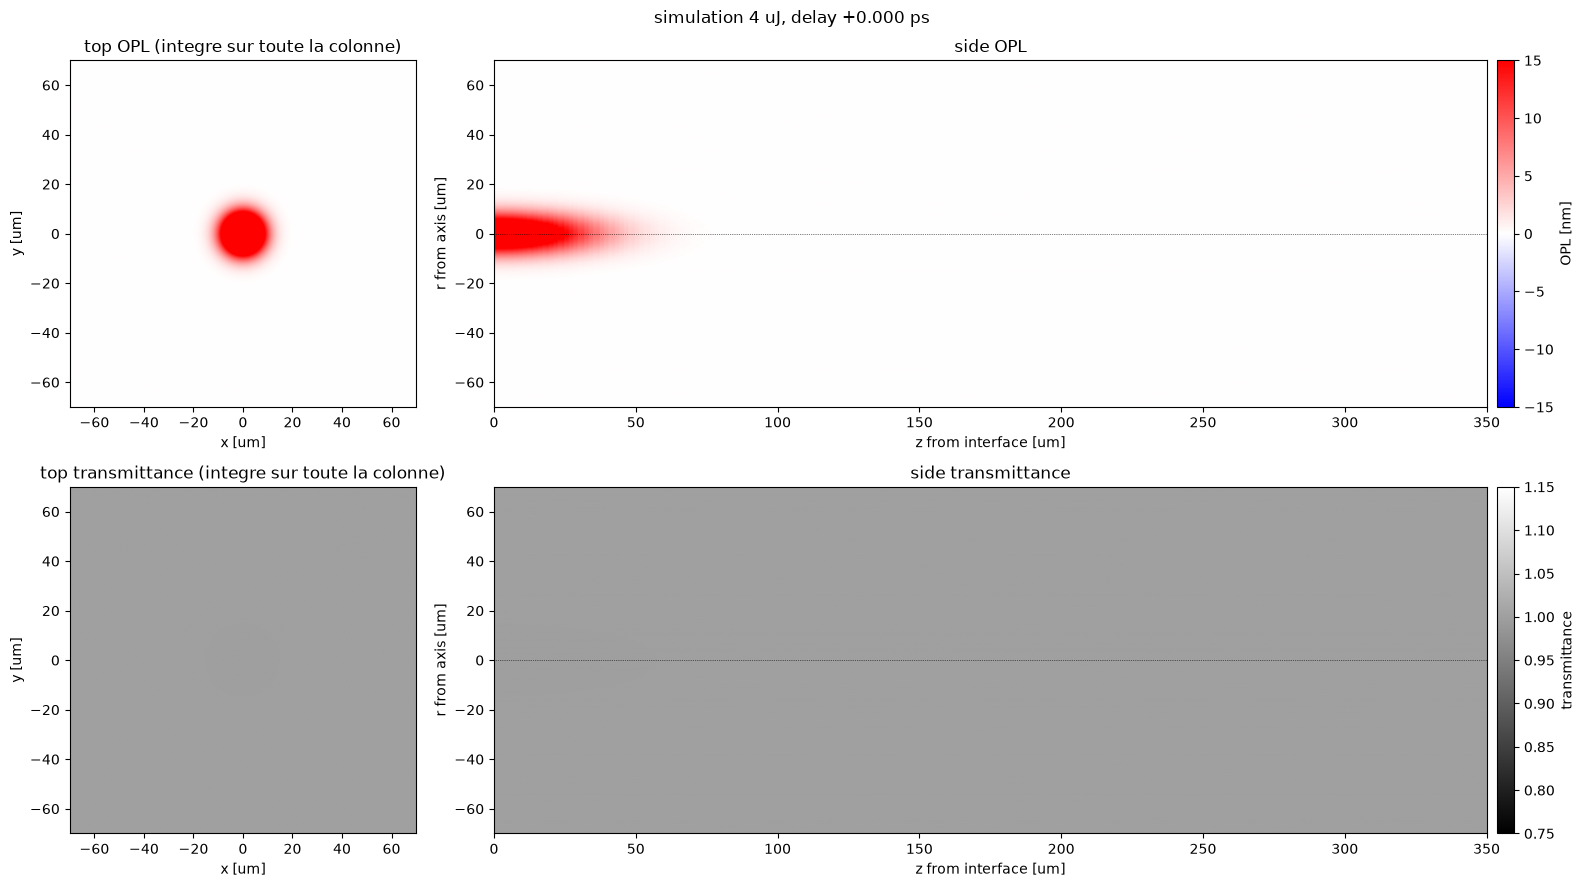

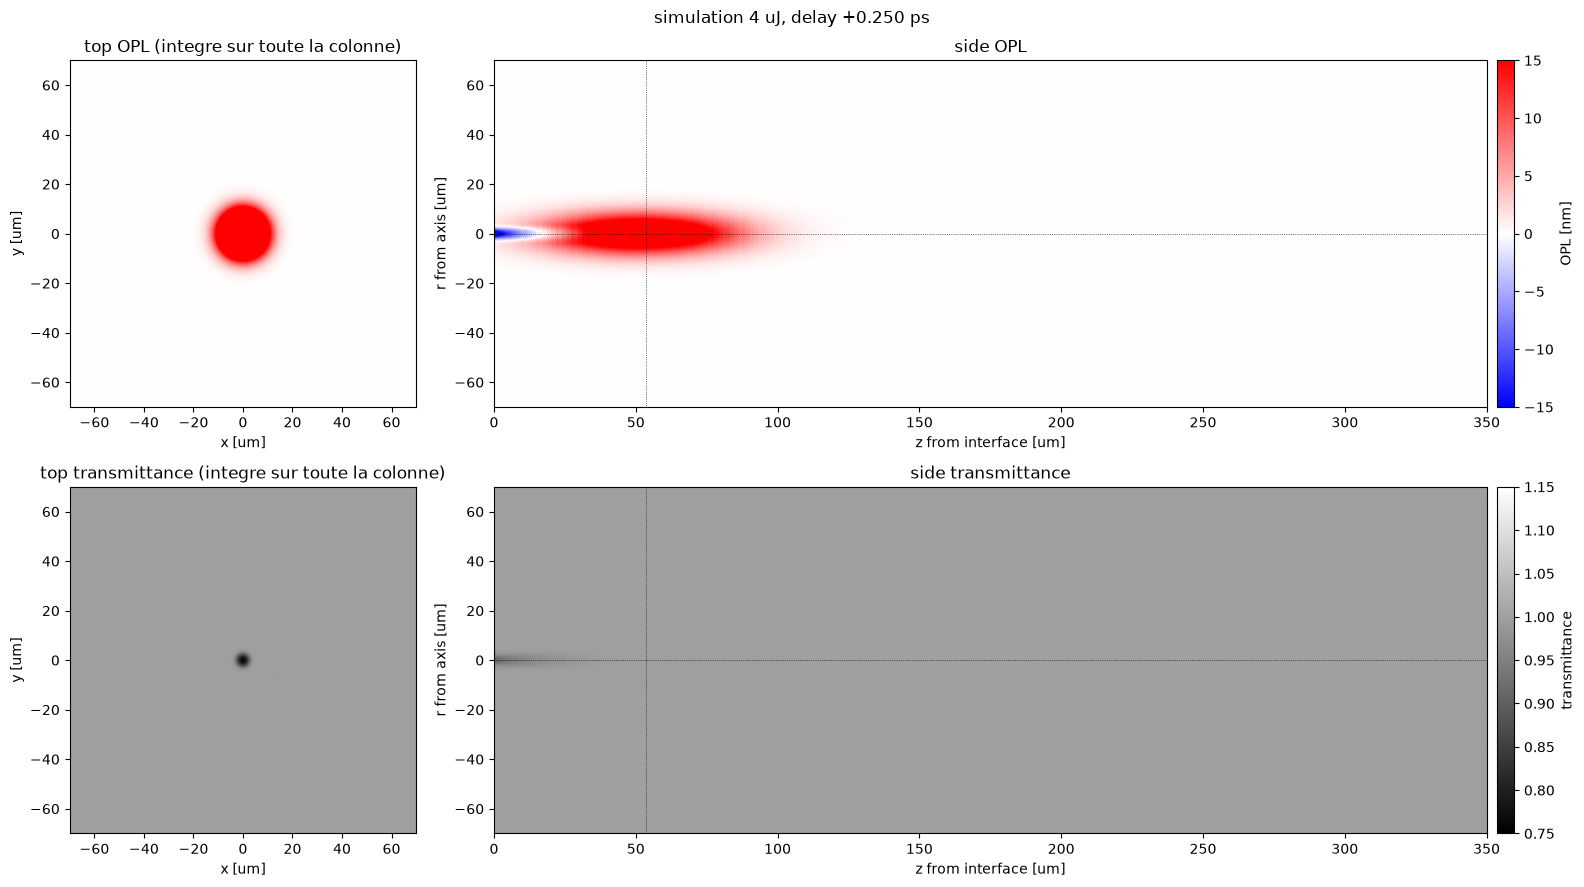

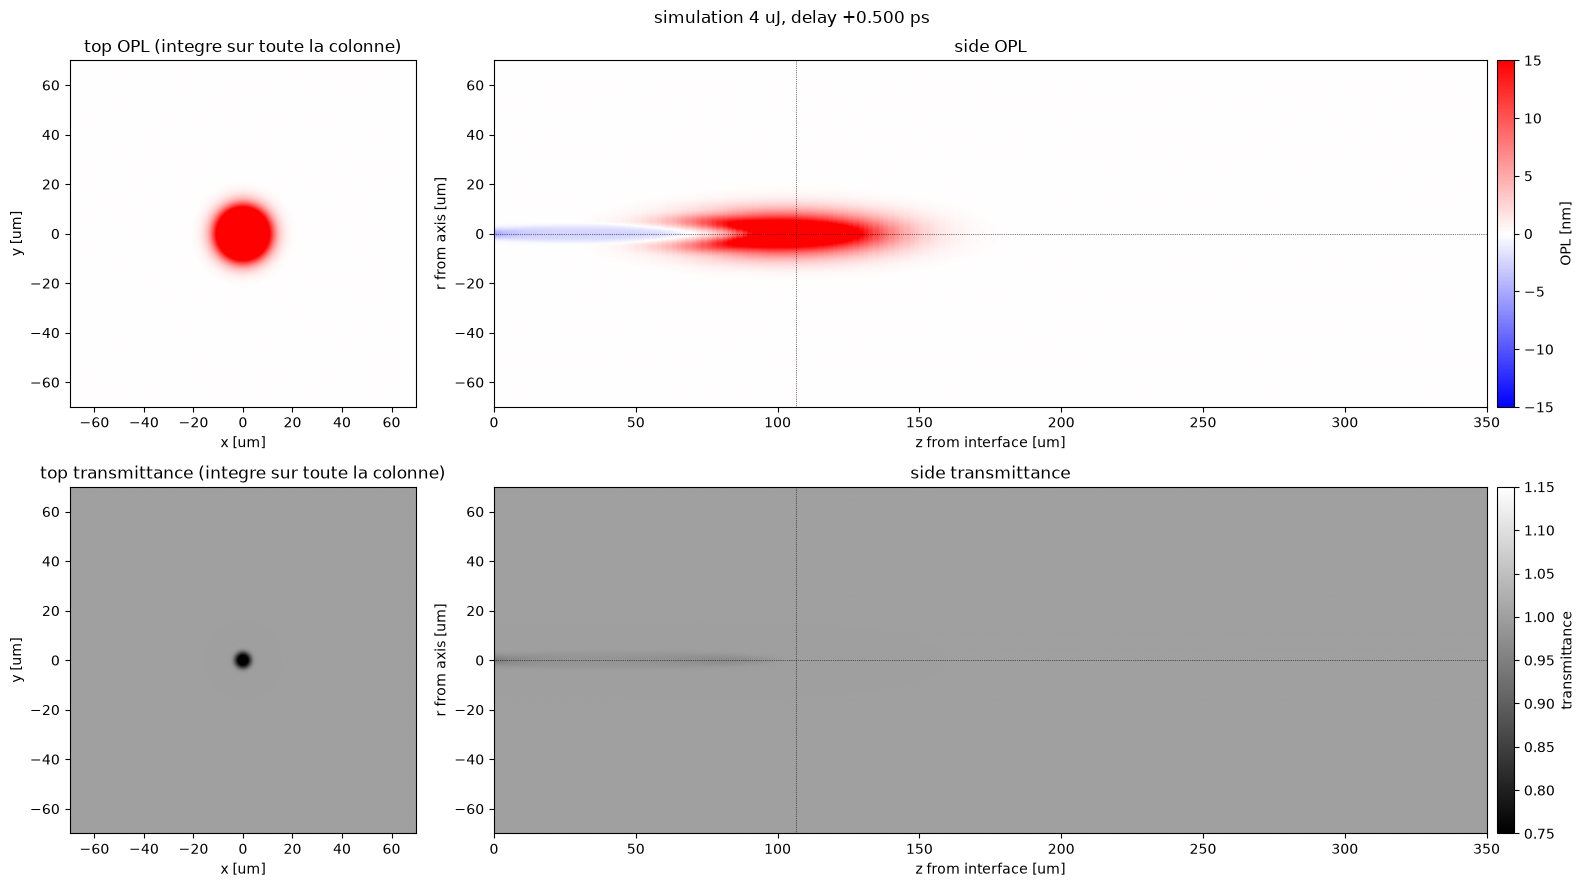

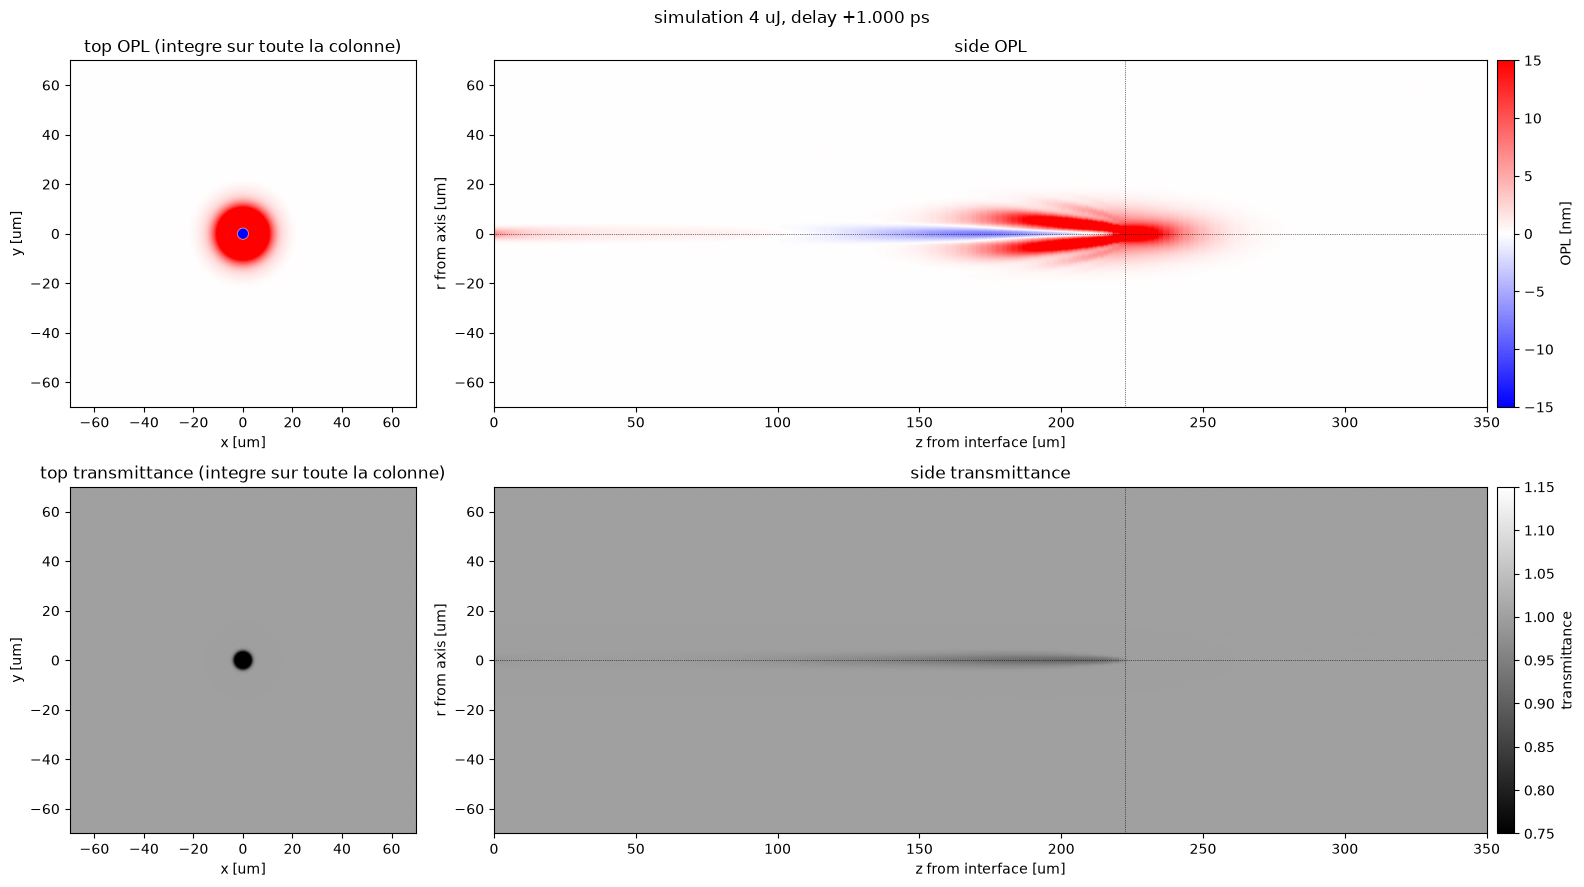

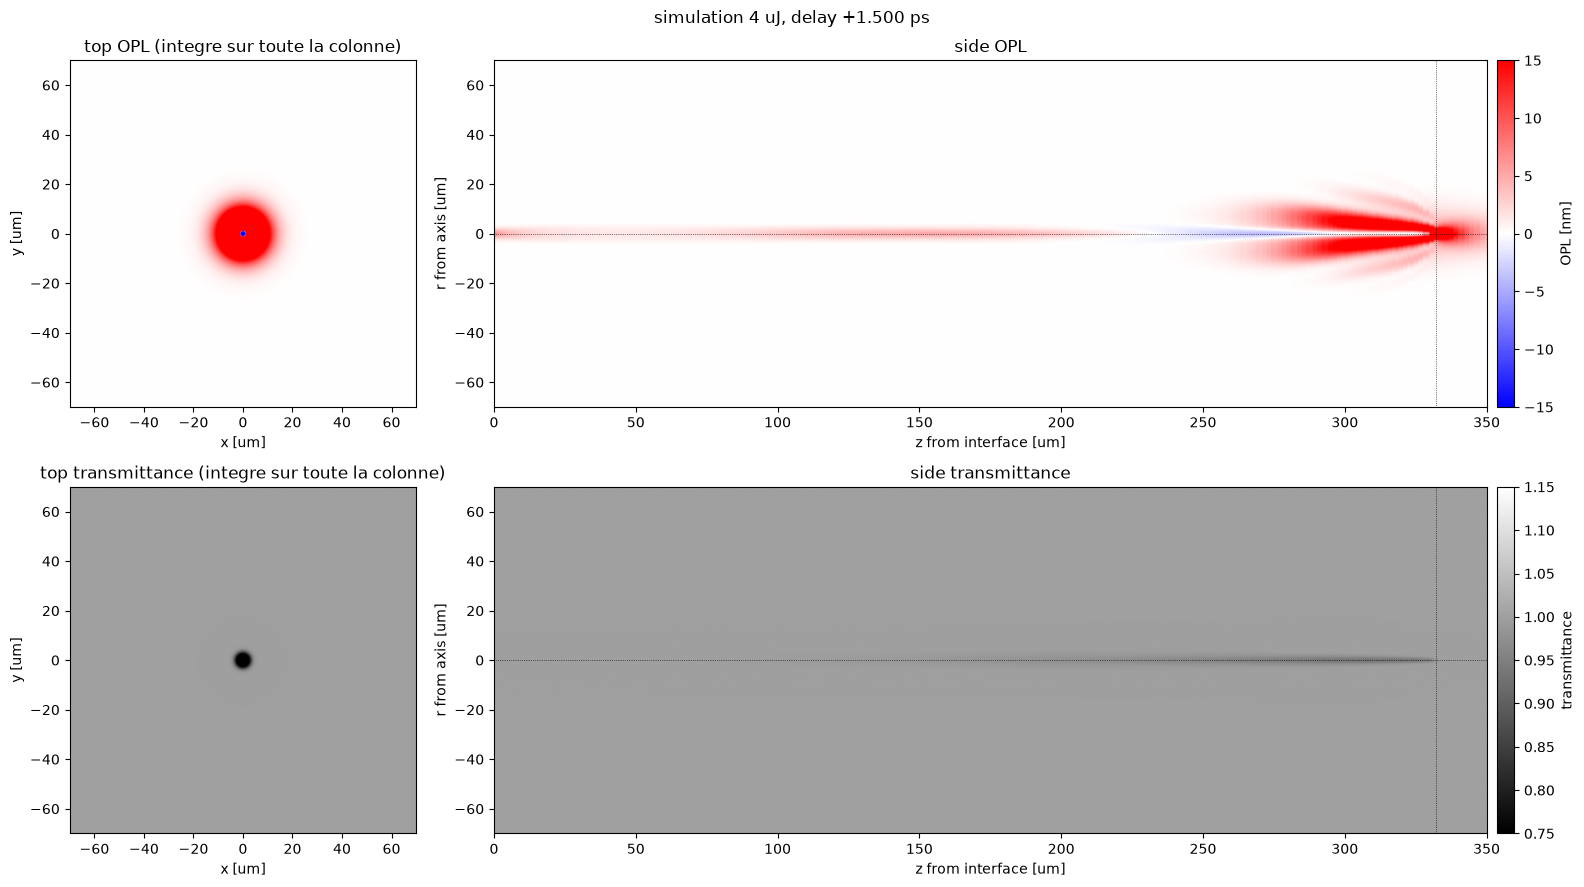

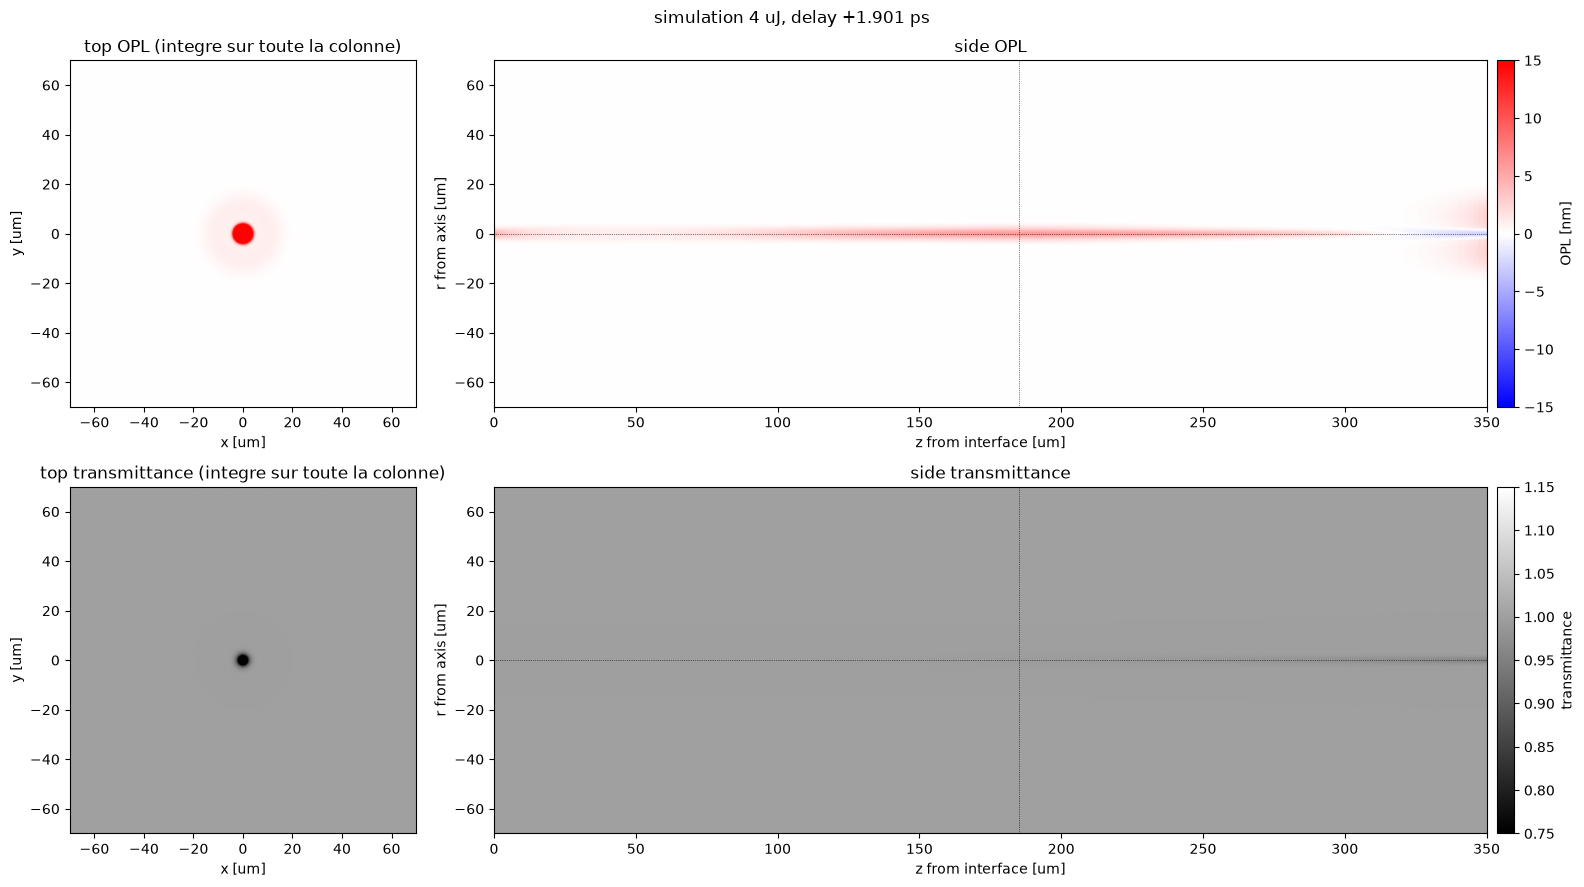

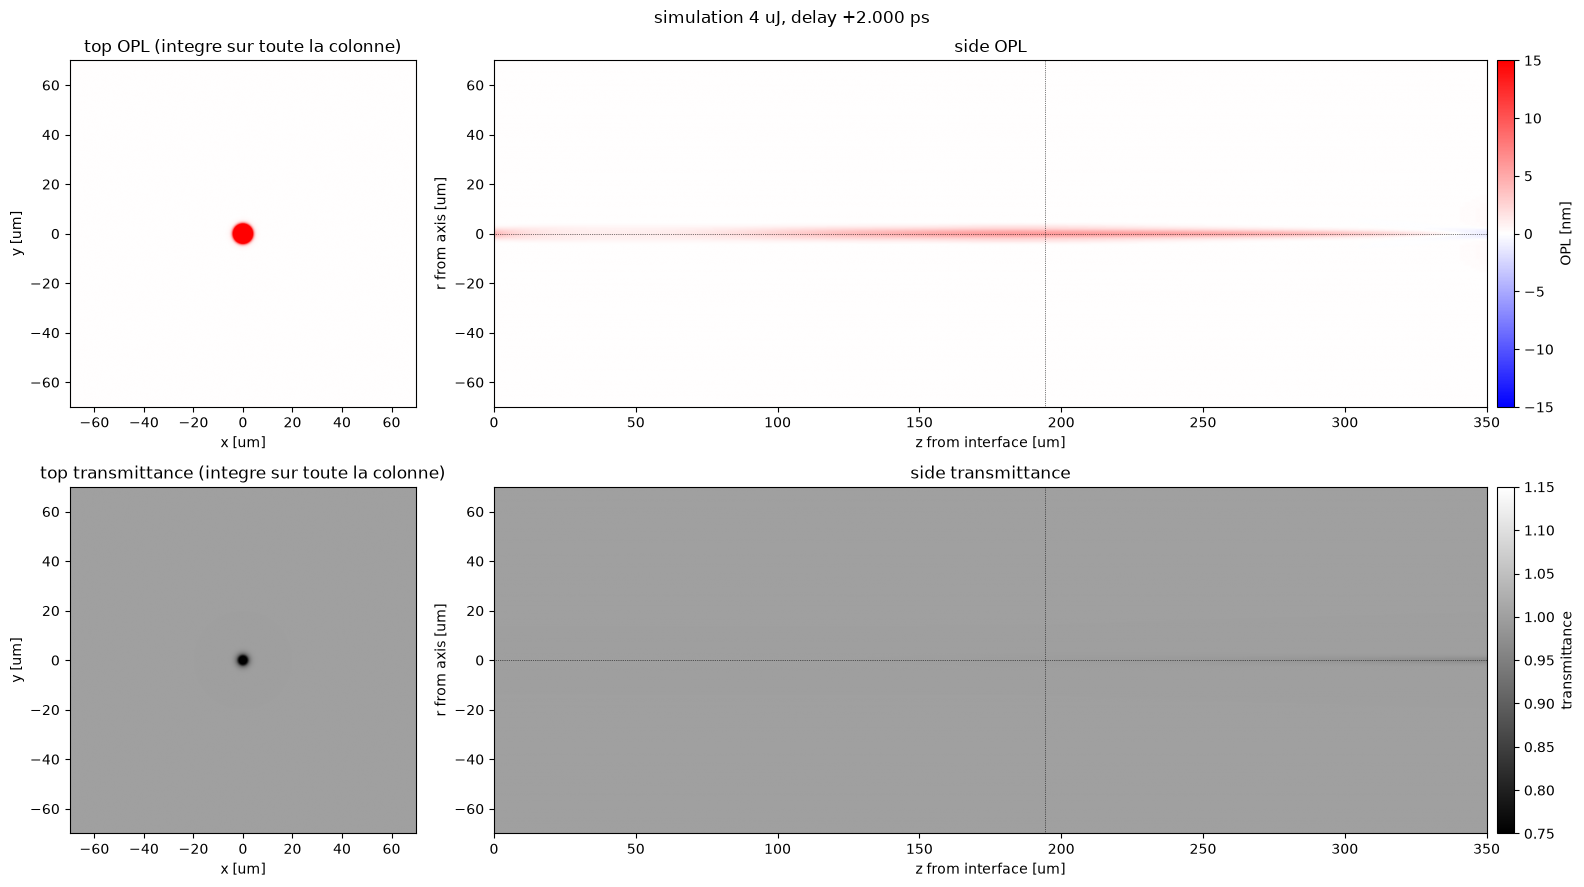

In [11]:
for delay in DELAYS_FS:
    fig, diag = ff.plot_opl_panel(
        res, delay_fs=float(delay),
        z_lim=Z_LIM_EXP, r_lim=R_LIM_EXP, x_half_um=X_HALF_UM,
        opl_clip_nm=15.0, t_lim=(0.75, 1.15),
        rho_max_cm3=RHO_MAX_CM3, validity_frac=0.1,
        title=f"simulation {ENERGY_INCIDENT_UJ:g} uJ, delay {delay/1000:+.3f} ps",
        save=str(FIG_DIR / f"delay_{delay:+05.0f}fs.png"),
        **PROBE_KW)
    print(f"{delay:+6.0f} fs :  OPL max = {np.abs(diag['opl_nm']).max():8.2f} nm"
          f"   T min = {diag['transmittance'].min():.3f}")

## 8. Décomposition par canal

In [12]:
for channels in (("drude",), ("ste",), ("kerr",), ("drude", "ste", "kerr")):
    diag = ff.probe_opl_transmittance(res, 0.0, include=channels,
                                      x_half_um=X_HALF_UM, **PROBE_KW)
    print(f"  0 fs  {str(channels):32s} OPL max = {np.abs(diag['opl_nm']).max():8.2f} nm")

print("\nExperience : OPL ~15 nm, transmittance ~0.75")

  0 fs  ('drude',)                       OPL max =     0.03 nm
  0 fs  ('ste',)                         OPL max =     0.00 nm
  0 fs  ('kerr',)                        OPL max =    26.84 nm
  0 fs  ('drude', 'ste', 'kerr')         OPL max =    26.80 nm

Experience : OPL ~15 nm, transmittance ~0.75


## 9. Figures pour le rapport

Une figure par point du `main.tex`. Elles sont toutes calculées depuis `result.npz`,
aucun recalcul de propagation.

| fichier | section illustrée | ce qu'elle montre |
|---|---|---|
| `rep_clamping_equilibrium.png` | filamentation | $n_2 I$ contre $\rho_e/2\rho_c$ le long de $z$, et le $\Delta n$ net |
| `rep_selffocusing.png` | filamentation | rayon simulé contre propagation linéaire, $z_R$ et $L_c$ |
| `rep_avalanche_takeover.png` | avalanche | instant où $\beta I \rho_e$ dépasse la graine multiphotonique |
| `rep_trapping_sequence.png` | excitons / STE | $\rho_e \to \rho_{STE}$ jusqu'à 2 ps |
| `rep_index_channels.png` | Kerr / défocalisation plasma | profil radial des trois canaux de $\Delta n$ |
| `rep_abel_illustration.png` | interférométrie | $\Delta n(r)$ vrai contre sa projection Abel |
| `rep_energy_budget.png` | équation de propagation | photoionisation contre chauffage Drude |


In [13]:
REPORT_DIAG = fr.export_report_figures(
    res, REP_DIR,
    wavelength_m=WAVELENGTH_M, n0=n0, n2=N2,
    w0_m=W0_M, energy_uJ=ENERGY_IN_GLASS_UJ, delta_t_s=DELTA_T_S,
    tau_c_s=TAU_C_S, Ui_eV=UI_EV, meff_rel=MEFF_REL, meff_drude_rel=MEFF_DRUDE_REL, begin_m=BEGIN_M, rho_max_cm3=RHO_MAX_CM3,
    tau_r_s=TAU_R_S, tau_ste_s=TAU_STE_S,
    lambda_probe_m=LAMBDA_PROBE_M, E_tr_eV=E_TR_EV,
    label=f"{ENERGY_INCIDENT_UJ:g} uJ",
    probe_kw=PROBE_KW)


rho_c (pompe 1030 nm, m*_Drude=1 m_e) = 1.051e+21 cm-3   facteur de collision 0.906
passages Kerr/plasma a l'equilibre : 0 ; premiers = []
rayon min simule = 11.25 um  (z_R = 559 um, L_c = 207 um, P/P_cr = 3.4)
avalanche : beta = 8.09 cm2/J, gain exp(int beta I dt) = 2.492e+03, bascule a -131 fs
pieges : rho_e max = 8.965e+19, rho_STE max = 6.540e+19 cm-3
canaux a z = 350 um : Kerr +1.316e-03, Drude -6.348e-03, STE +1.188e-03
OPL projete max = 19.15 nm = 0.234 rad
pertes totales = 14.0 % de U0
-> runs_z0/figures_rapport


### 9.1 Réglages individuels

Si une figure demande un autre plan ou un autre délai, la fonction correspondante
se rappelle seule ; `save=` écrase le PNG.


regenerees


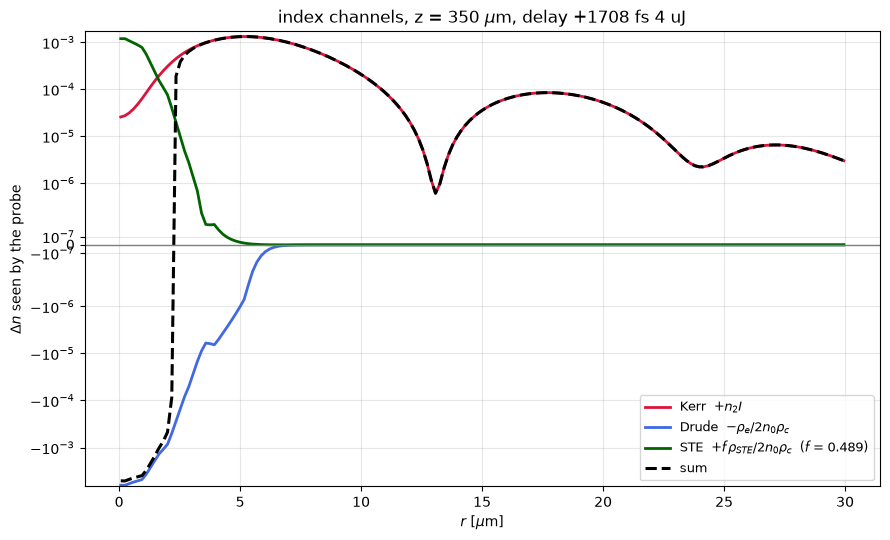

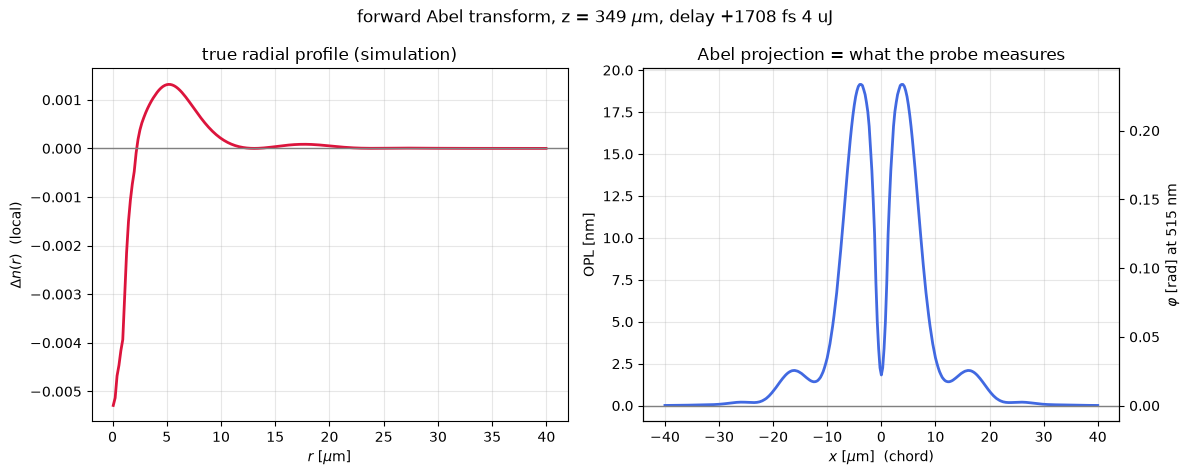

In [14]:
# plan le plus intense par defaut ; z_target_um=... pour en choisir un autre
# delay_fs=None -> au passage de la pompe sur le plan trace
fr.plot_index_channels(res, delay_fs=None, lambda_probe_m=LAMBDA_PROBE_M,
                       E_tr_eV=E_TR_EV, n2=N2, tau_r_s=TAU_R_S,
                       tau_ste_s=TAU_STE_S, r_max_um=30.0,
                       label=f"{ENERGY_INCIDENT_UJ:g} uJ",
                       save=str(REP_DIR / "rep_index_channels.png"))

fr.plot_abel_illustration(res, delay_fs=None, x_half_um=40.0,
                          label=f"{ENERGY_INCIDENT_UJ:g} uJ",
                          save=str(REP_DIR / "rep_abel_illustration.png"),
                          **PROBE_KW)
print("regenerees")


### 9.2 Copie vers le projet LaTeX

Les `\includegraphics` du rapport cherchent les PNG à la racine de
`latex_project_text/`.


In [15]:
import shutil

TEX_DIR = Path("../../latex_project_text").resolve()
if TEX_DIR.is_dir():
    for png in sorted(REP_DIR.glob("rep_*.png")):
        shutil.copy2(png, TEX_DIR / png.name)
        print("->", TEX_DIR / png.name)
else:
    print(f"{TEX_DIR} introuvable : copie manuelle des PNG de {REP_DIR}")


/workspace/latex_project_text introuvable : copie manuelle des PNG de runs_z0/figures_rapport


## 10. Export pour comparaison avec la mesure

Trois sorties, de la plus légère à la plus lourde :

1. **`curve_4uJ.csv`** — la courbe δφ(τ) et la transmittance, quelques ko.
   C'est ce fichier qu'il faut partager.
2. **`result_small.npz`** — le run réduit aux seuls cubes utiles au
   post-traitement sonde, pour pouvoir refaire les cartes ailleurs.
3. La planche de superposition, points simulés sur courbe modèle.


In [17]:
from virtual_experiment import (NOMARSKI_515, experimental_delay_grid,
                                sample_as_experiment, plot_experiment_overlay)
from export_curves import shrink_result_npz, export_probe_curve

# plan de lecture : au milieu du canal, pas au bord de la boite
Z_READ_UM = 150.0
X_READ_UM = 0.0

GRID_FINE = experimental_delay_grid(fine=(-1000.0, 2000.0, 33.0), coarse_ps=())
print(f"{len(GRID_FINE)} delais, de {GRID_FINE[0]:.0f} a {GRID_FINE[-1]:.0f} fs\n")

pts = sample_as_experiment(res, GRID_FINE, NOMARSKI_515,
                           z_um=Z_READ_UM, x_um=X_READ_UM,
                           x_half_um=X_HALF_UM, oversample=5, **PROBE_KW)
print(f"phase simulee : {pts['phase_rad'].min():+.3f} a {pts['phase_rad'].max():+.3f} rad")
print(f"transmittance : {pts['transmittance'].min():.3f} a {pts['transmittance'].max():.3f}")


92 delais, de -1000 a 2003 fs

phase simulee : -0.044 a +0.160 rad
transmittance : 0.913 a 1.028


In [18]:
# --- 1. la courbe seule, quelques ko : C'EST CE FICHIER QU'IL FAUT PARTAGER ---
export_probe_curve(res, OUT_ROOT / f"curve_{ENERGY_INCIDENT_UJ:g}uJ.npz",
                   delays_fs=GRID_FINE, inst=NOMARSKI_515,
                   z_um=Z_READ_UM, x_um=X_READ_UM,
                   x_half_um=X_HALF_UM, oversample=5, **PROBE_KW)


-> curve_4uJ.npz (3.7 ko) et curve_4uJ.csv


PosixPath('runs_z0/curve_4uJ.npz')

In [19]:
# --- 2. le run reduit, pour refaire les cartes ailleurs ---
shrink_result_npz(OUT_ROOT / f"z0_350um_{ENERGY_INCIDENT_UJ:g}uJ",
                  OUT_ROOT / "result_small.npz", z_stride=4, t_stride=1)


result.npz :    399.4 Mo
result_small.npz :     95.4 Mo   (facteur 4)
  resolution en delai conservee : 8.7 fs
  cubes conserves : ['rho_rzt', 'rho_s_rzt', 'I_rzt']
  /!\ ce fichier ne sert QU'AU post-traitement sonde ; les diagnostics de propagation (fluence, Ipeak, pertes resolues) n'y sont pas.


PosixPath('runs_z0/result_small.npz')

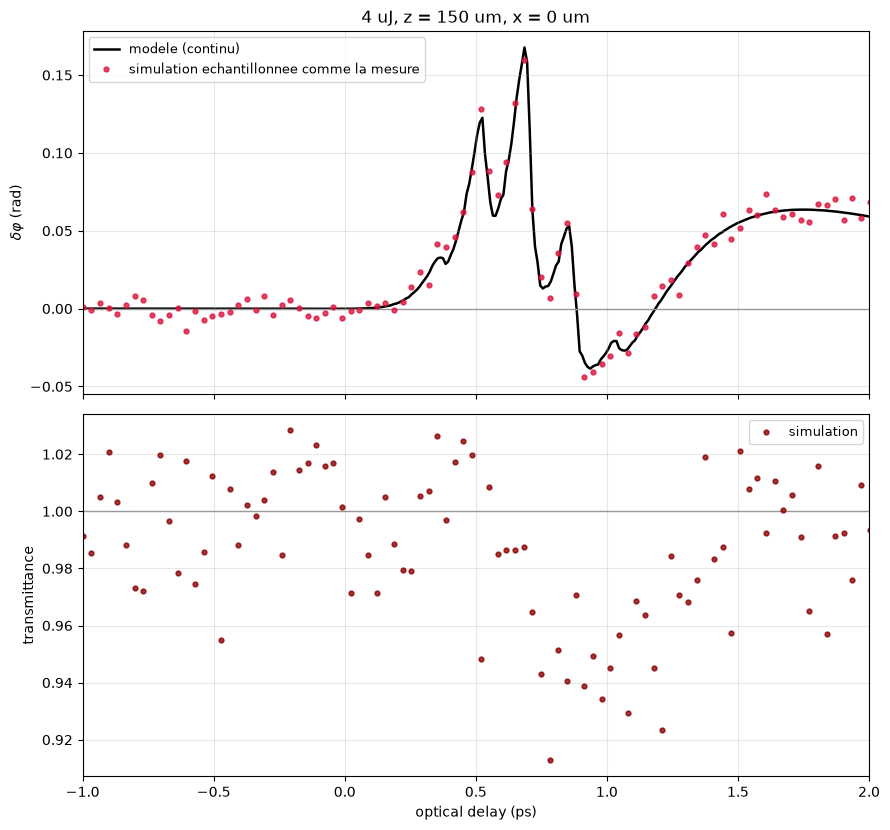

In [20]:
# --- 3. superposition points / modele ---
mod = sample_as_experiment(res, np.linspace(-1000.0, 2000.0, 300), NOMARSKI_515,
                           z_um=Z_READ_UM, x_um=X_READ_UM, add_noise=False,
                           x_half_um=X_HALF_UM, oversample=5, **PROBE_KW)

plot_experiment_overlay(
    pts, model=dict(delays_fs=mod["delays_fs"], phase_rad=mod["phase_rad"]),
    measured=None,          # <- mettre ici measured_phase_curve(...) quand tu l'auras
    xlim_ps=(-1.0, 2.0),
    title=f"{ENERGY_INCIDENT_UJ:g} uJ, z = {Z_READ_UM:.0f} um, x = {X_READ_UM:.0f} um",
    save=str(FIG_DIR / "overlay_sim_vs_exp.png"));


### 10.1 Quand tu auras la courbe mesurée

Elle n'est pas à acquérir : c'est une coupe le long de l'axe des délais dans la
pile de frames déjà enregistrée — un pixel de chacune des N frames du balayage.


In [21]:
from export_curves import measured_phase_curve
from virtual_experiment import compare_to_measurement

meas = measured_phase_curve("chemin/vers/les/frames", pattern="*.npz",
                             x_um=X_READ_UM, z_um=Z_READ_UM, average_x_um=1.0)
plot_experiment_overlay(pts,model=dict(delays_fs=mod["delays_fs"], phase_rad=mod["phase_rad"]),
                        measured=meas, save=str(FIG_DIR / "overlay_sim_vs_exp.png"))
compare_to_measurement(pts, meas)


FileNotFoundError: aucun fichier *.npz dans chemin/vers/les/frames